In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ChestXRay'

Mounted at /content/drive


In [2]:
!pip install torchvision matplotlib seaborn scikit-learn

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("All imports done!")

All imports done!


In [4]:
data_dir = '/content/drive/MyDrive/ChestXRay'

for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(data_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


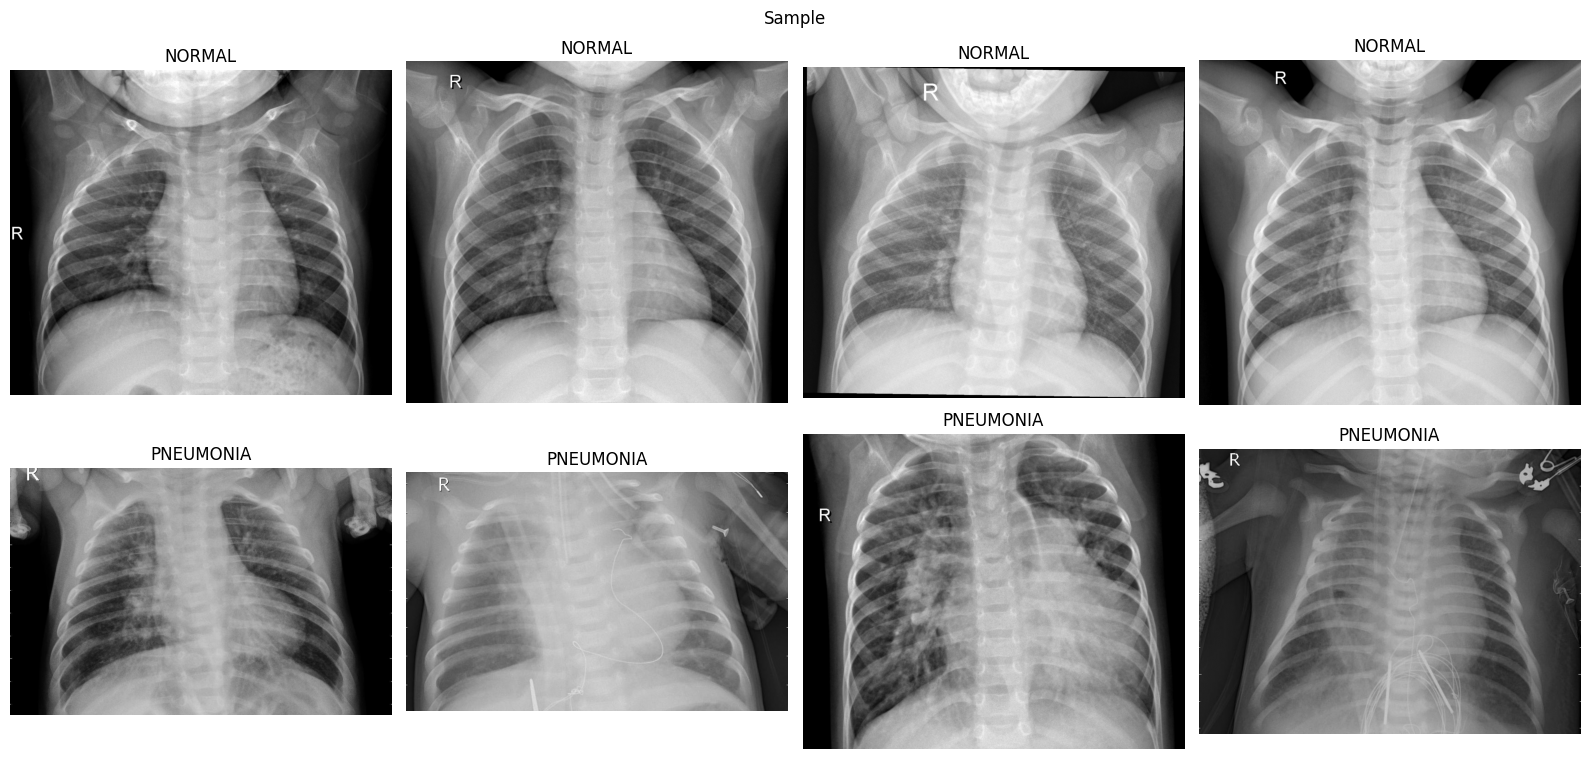

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(data_dir, 'train', label)
    images = os.listdir(folder)[:4]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name)).convert('L')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(label)
        axes[row][col].axis('off')

plt.suptitle("Sample")
plt.tight_layout()
plt.show()

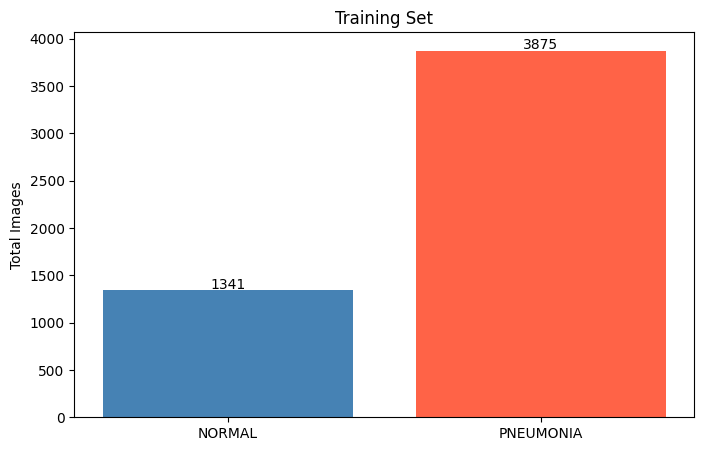

In [8]:
labels = ['NORMAL', 'PNEUMONIA']
train_counts = [
    len(os.listdir(os.path.join(data_dir, 'train', 'NORMAL'))),
    len(os.listdir(os.path.join(data_dir, 'train', 'PNEUMONIA')))
]

plt.figure(figsize=(8, 5))
plt.bar(labels, train_counts, color=['steelblue', 'tomato'])
plt.title('Training Set')
plt.ylabel('Total Images')
for i, v in enumerate(train_counts):
    plt.text(i, v + 20, str(v), ha='center')
plt.show()


In [10]:
from torchvision import datasets
from torch.utils.data import ConcatDataset, random_split


raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])


train_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=raw_transform)
val_raw   = datasets.ImageFolder(os.path.join(data_dir, 'val'),   transform=raw_transform)

combined = ConcatDataset([train_raw, val_raw])
total = len(combined)
print(f"Total images for train+val: {total}")




Total images for train+val: 5232


In [11]:
train_size = int(0.85 * total)
val_size   = total - train_size

train_dataset, val_dataset = random_split(
    combined,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size}, Val: {val_size}")

Train: 4447, Val: 785
